## libs import

In [11]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## connection

In [12]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

In [13]:
first_10_rows_query = "SELECT * FROM checker LIMIT 5;"
first_10_rows = pd.io.sql.read_sql(first_10_rows_query, connection)
print(first_10_rows)

   index    status  success                   timestamp  numTrials   labname  \
0      0  checking        0  2020-04-16 21:12:50.740474          5      None   
1      1     ready        0  2020-04-16 21:12:54.708365          5  code_rvw   
2      2  checking        0  2020-04-16 21:46:47.769088          7      None   
3      3     ready        0  2020-04-16 21:46:48.121217          7     lab02   
4      4  checking        0  2020-04-16 21:53:01.862637          6  code_rvw   

       uid  
0  admin_1  
1  admin_1  
2  admin_1  
3  admin_1  
4  admin_1  


## query for date, trials from checker for users in project1

In [19]:
query = """
SELECT timestamp, uid
FROM checker
WHERE uid LIKE 'user_%' AND status = 'ready' AND labname = 'project1';
"""
df = pd.read_sql_query(query, connection)
df['date'] = pd.to_datetime(df['timestamp']).dt.date
df.drop('timestamp', axis=True, inplace=True)

## df preprocessing

In [69]:
df_commits_counts = df.value_counts().reset_index().sort_values(by='date')

In [70]:
df_commits_counts['cumsum_commits'] = df_commits_counts.groupby(by=['uid'])['count'].cumsum()

In [109]:
df_commits_counts.drop('count', axis=1).head()

,uid,date,cumsum_commits
41,user_4,2020-04-17,7
80,user_17,2020-04-18,1
51,user_4,2020-04-19,11
88,user_30,2020-04-22,1
89,user_30,2020-04-23,2


In [126]:
additional_rows = []

for user in df_commits_counts['uid'].unique():
    user_data = df_commits_counts[df_commits_counts['uid'] == user]
    first_date = user_data['date'].min()  # Первая дата
    previous_date = first_date - pd.Timedelta(days=1)  # Предыдущая дата
    additional_rows.append({'uid': user, 'date': previous_date, 'count': 0, 'cumsum_commits': 0})

In [139]:
additional_df = pd.DataFrame(additional_rows)
df_combined = pd.concat([df_commits_counts, additional_df], ignore_index=True).sort_values(by=['uid', 'date'])

## Plot. Dynamic of commits per user in project1

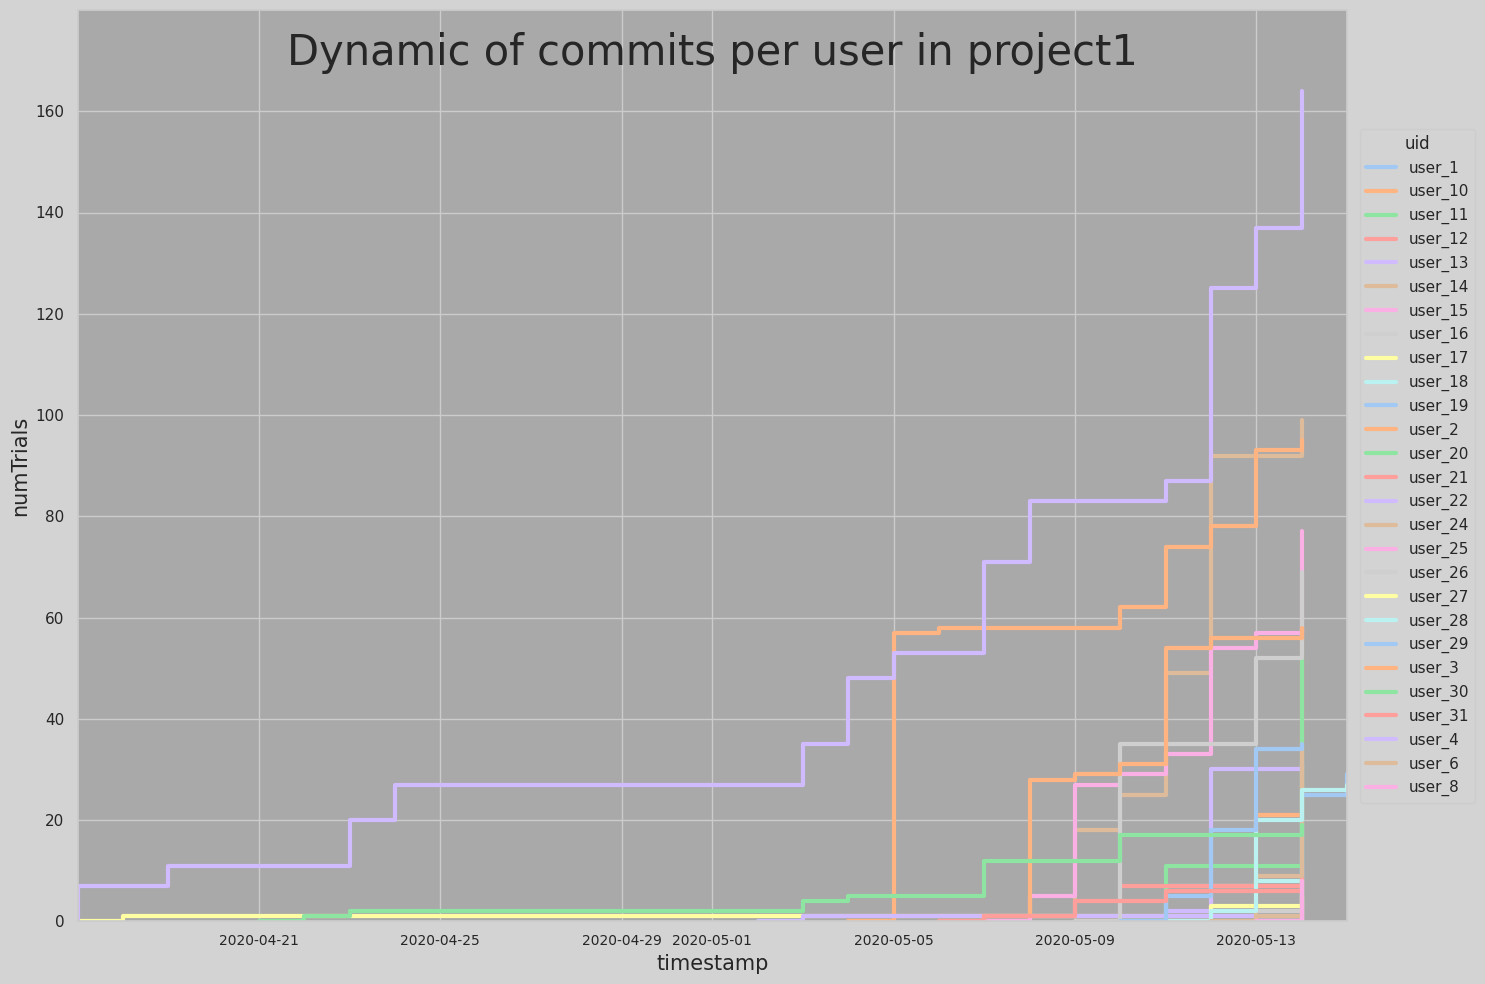

In [172]:
fig, ax = plt.subplots(figsize=(15, 10))
fig.set_facecolor('lightgray')
ax.set_facecolor('darkgray')

# Стиль Seaborn
sns.set_theme(style="whitegrid")

# Палитра цветов
palette = sns.color_palette("pastel")

# Построение графиков для каждого пользователя
for i, user in enumerate(df_combined.uid.unique()):
    user_data = df_combined[df_combined['uid'] == user]
    ax.step(data=user_data, x='date', y='cumsum_commits', where="post", linewidth=3, 
            label=user, color=palette[i % len(palette)])

# Настройка заголовка и меток осей
ax.set_title('Dynamic of commits per user in project1', fontsize=30, y = 0.93)
ax.set_xlabel('timestamp', fontsize=15)
ax.set_ylabel('numTrials', fontsize=15)
yticks = range(0, 181, 20)
ax.set_yticks(yticks[:-1])  # Исключаем последнюю метку
ax.set_ylim(yticks[0], yticks[-1])  # Устанавливаем границы оси Y (исключаем последнюю метку)

# Убираем первую метку на оси X
current_xticks = ax.get_xticks()
current_labels = ax.get_xticklabels()
ax.set_xticks(current_xticks[1:])
ax.set_xticklabels([label.get_text() for label in current_labels[1:]], ha='center', fontsize=10)

# Установка границ оси X
ax.set_xlim(df_combined['date'].min() + pd.Timedelta(days=1), df_combined['date'].max())

# Настройка легенды
legend = ax.legend(title='uid', bbox_to_anchor=(1.01, 0.5), loc='center left', 
                   borderaxespad=0.0, facecolor='lightgray')

plt.tight_layout()

## Answer for questions:

### “Which user was the leader in the number of commits almost all of the time?” The answer: user_4.
### “Which user was the leader for only a short period of time?” The answer: user_2.

## connectiond close

In [173]:
connection.close()